EDA Findings
1.SIP transactions contribute about 60% of total transactions.
2.Verified KYC investors dominate the dataset.
3.Nippon India MF has the highest AUM among fund houses.
4.DSP Mutual Fund has the highest average expense ratio.
5.Return metrics show strong positive correlation.
6.Sharpe Ratio and Sortino Ratio are highly correlated.
7.Higher drawdowns are generally associated with lower Sharpe ratios.
8.Most funds have expense ratios between 1% and 1.6%.
9.AUM is concentrated among a few large fund houses.
10.NAV values generally show an upward trend from 2022–2026.
11.Most funds have beta values clustered around the market average.
12.Drawdown values are concentrated within a moderate risk range.
13.Higher-rated funds tend to dominate the dataset.
14.Expense ratio shows only a weak relationship with returns.
15.Funds with higher alpha generally exhibit stronger Sharpe ratios.

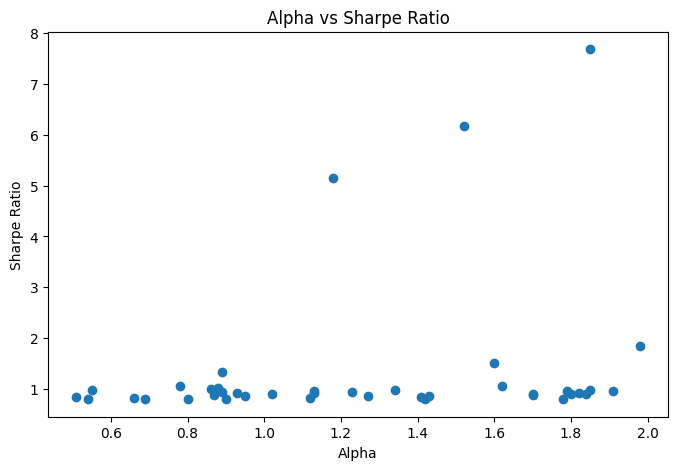

In [5]:
# Chart 16: Sharpe Ratio vs Alpha
plt.figure(figsize=(8,5))

plt.scatter(
    performance["alpha"],
    performance["sharpe_ratio"]
)

plt.xlabel("Alpha")
plt.ylabel("Sharpe Ratio")
plt.title("Alpha vs Sharpe Ratio")

plt.show()

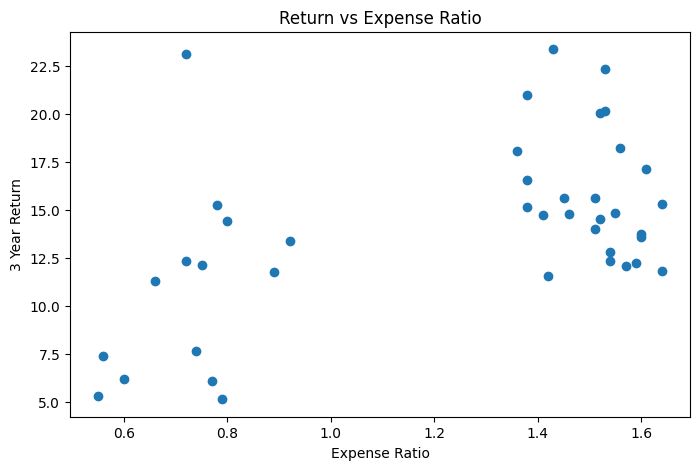

In [6]:
# Chart 15: Return vs Expense Ratio
plt.figure(figsize=(8,5))

plt.scatter(
    performance["expense_ratio_pct"],
    performance["return_3yr_pct"]
)

plt.xlabel("Expense Ratio")
plt.ylabel("3 Year Return")
plt.title("Return vs Expense Ratio")

plt.show()

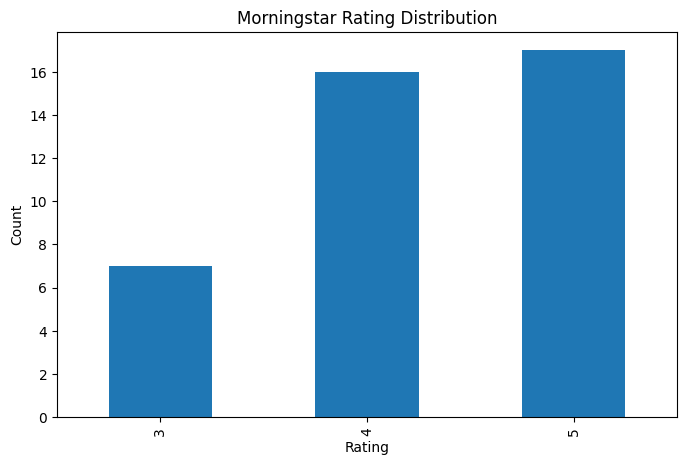

In [7]:
# Chart 14: Morningstar Rating Distribution
plt.figure(figsize=(8,5))

performance["morningstar_rating"].value_counts() \
    .sort_index() \
    .plot(kind="bar")

plt.title("Morningstar Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

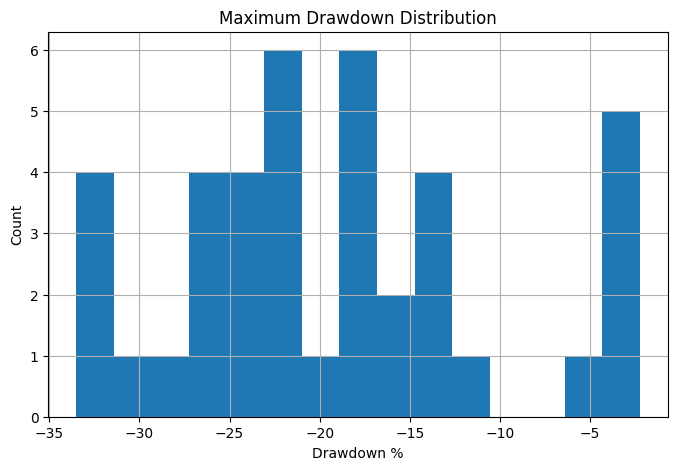

In [8]:
# Chart 13: Drawdown Distribution
plt.figure(figsize=(8,5))

performance["max_drawdown_pct"].hist(bins=15)

plt.title("Maximum Drawdown Distribution")
plt.xlabel("Drawdown %")
plt.ylabel("Count")

plt.show()

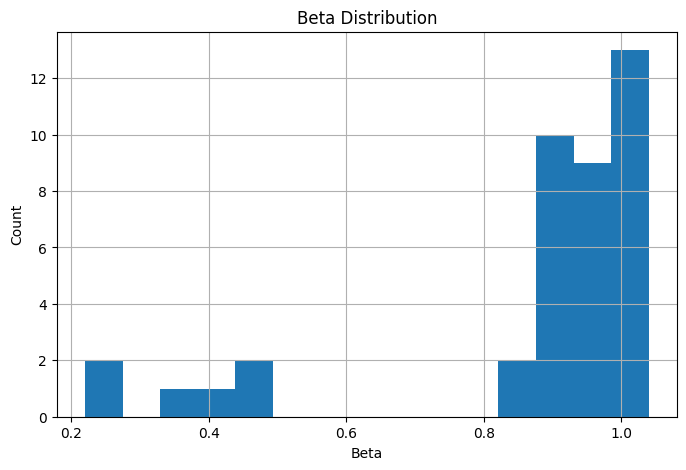

In [9]:
# Chart 12: Beta Distribution
plt.figure(figsize=(8,5))

performance["beta"].hist(bins=15)

plt.title("Beta Distribution")
plt.xlabel("Beta")
plt.ylabel("Count")

plt.show()

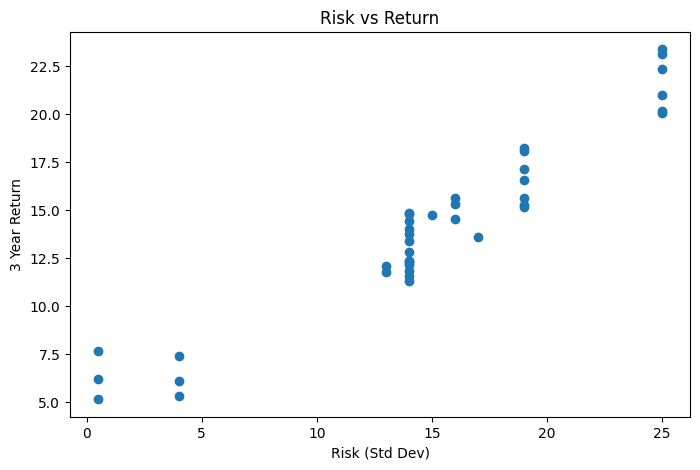

In [10]:
# Chart 11: Risk vs Return
plt.figure(figsize=(8,5))

plt.scatter(
    performance["std_dev_ann_pct"],
    performance["return_3yr_pct"]
)

plt.xlabel("Risk (Std Dev)")
plt.ylabel("3 Year Return")
plt.title("Risk vs Return")
plt.show()

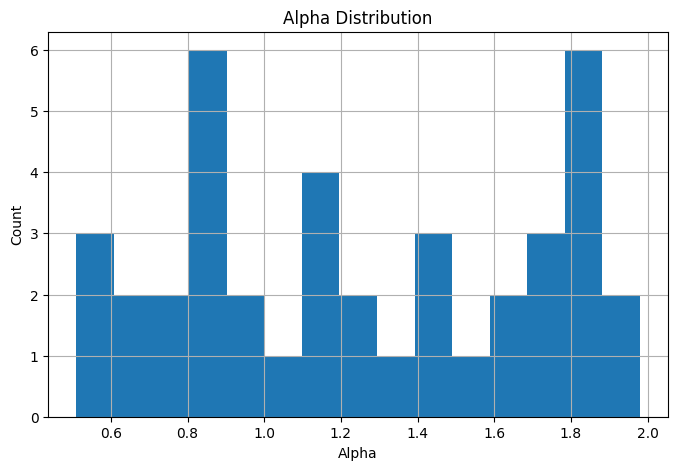

In [11]:
# Chart 10: Alpha Distribution
plt.figure(figsize=(8,5))
performance["alpha"].hist(bins=15)
plt.title("Alpha Distribution")
plt.xlabel("Alpha")
plt.ylabel("Count")
plt.show()

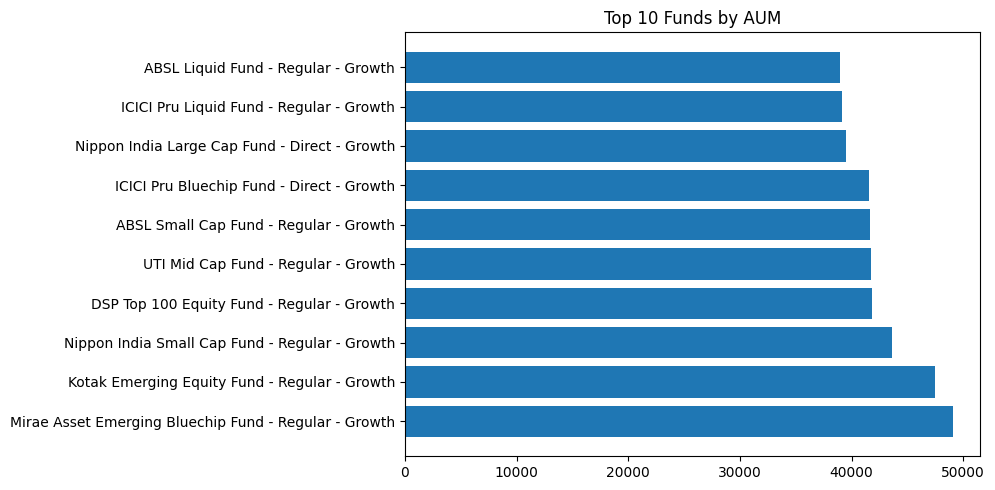

In [12]:
# Chart 9: Top 10 Funds by AUM
top_aum = performance.sort_values(
    "aum_crore",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
plt.barh(
    top_aum["scheme_name"],
    top_aum["aum_crore"]
)
plt.title("Top 10 Funds by AUM")
plt.tight_layout()
plt.show()

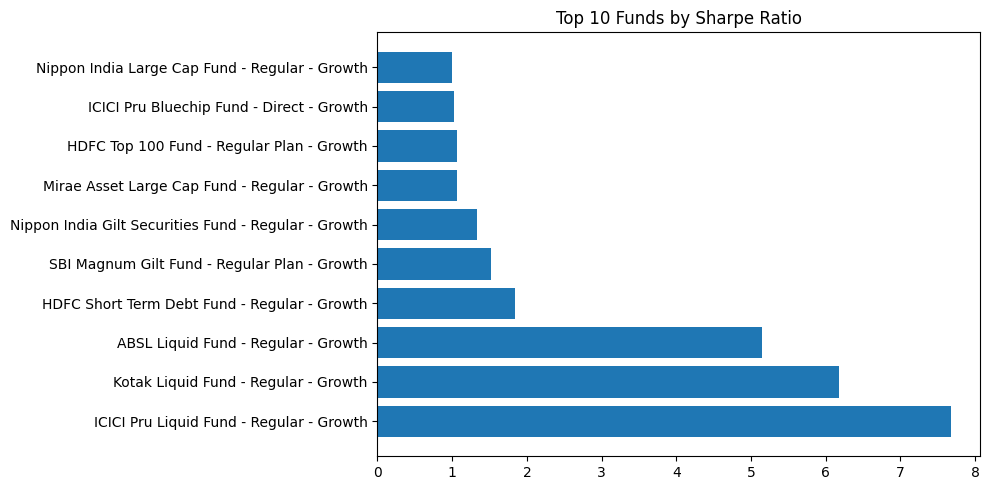

In [13]:
# Chart 8: Top 10 Funds by Sharpe Ratio
top_sharpe = performance.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
plt.barh(
    top_sharpe["scheme_name"],
    top_sharpe["sharpe_ratio"]
)
plt.title("Top 10 Funds by Sharpe Ratio")
plt.tight_layout()
plt.show()

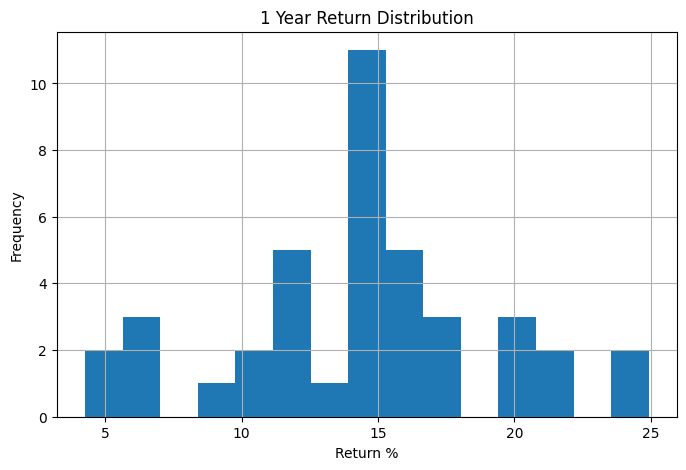

In [14]:
# Chart 7: Return Distribution Histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
performance["return_1yr_pct"].hist(bins=15)
plt.title("1 Year Return Distribution")
plt.xlabel("Return %")
plt.ylabel("Frequency")
plt.show()

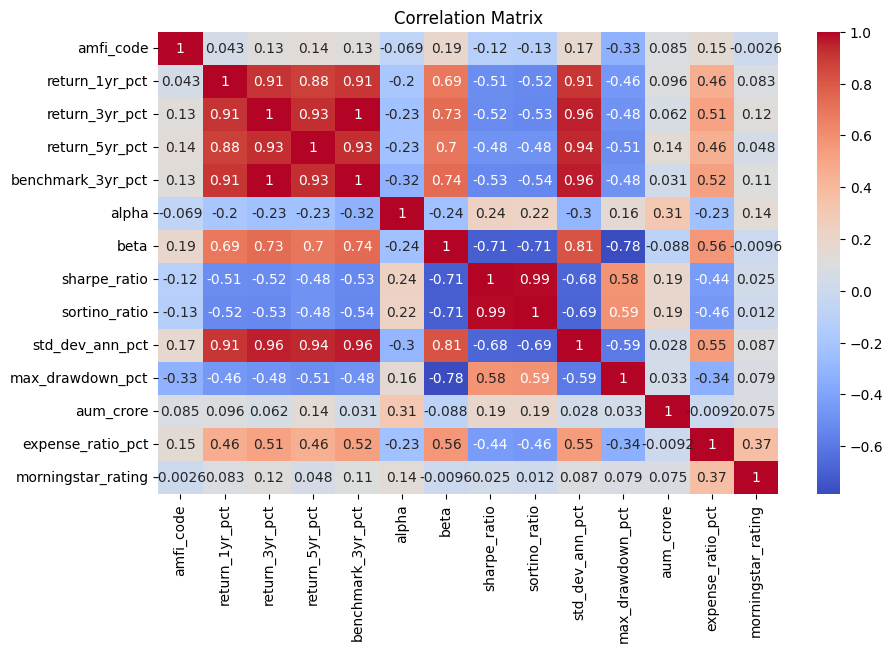

In [15]:
# Chart 6: Correlation Heatmap
corr = performance.select_dtypes(
    include="number"
).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

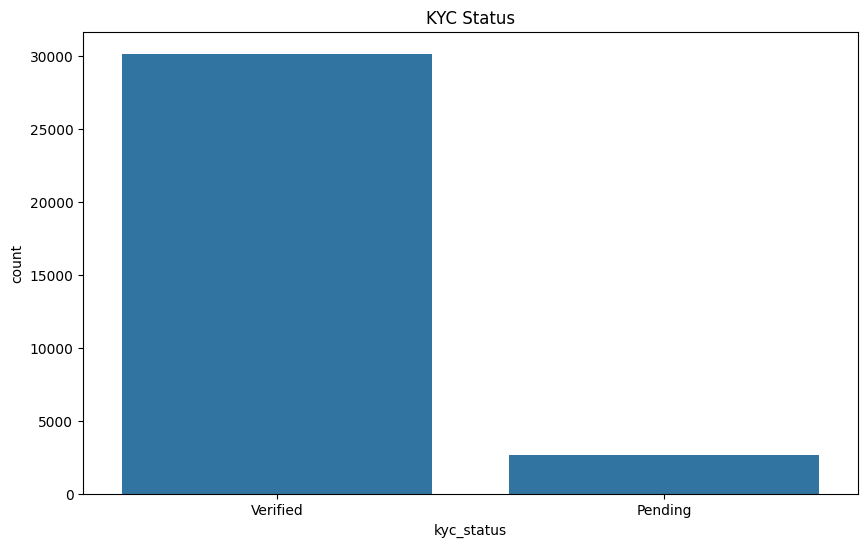

In [16]:
# Chart 5: KYC Status
sns.countplot(
    x="kyc_status",
    data=transactions
)

plt.title("KYC Status")
plt.show()

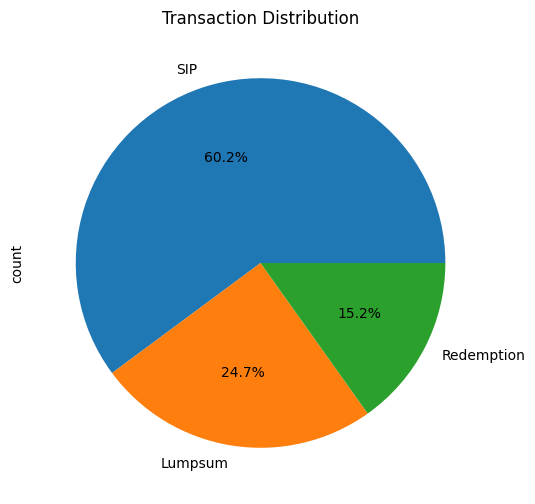

In [17]:
# Chart 4: Investor Transaction Types
transactions["transaction_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Transaction Distribution")
plt.show()

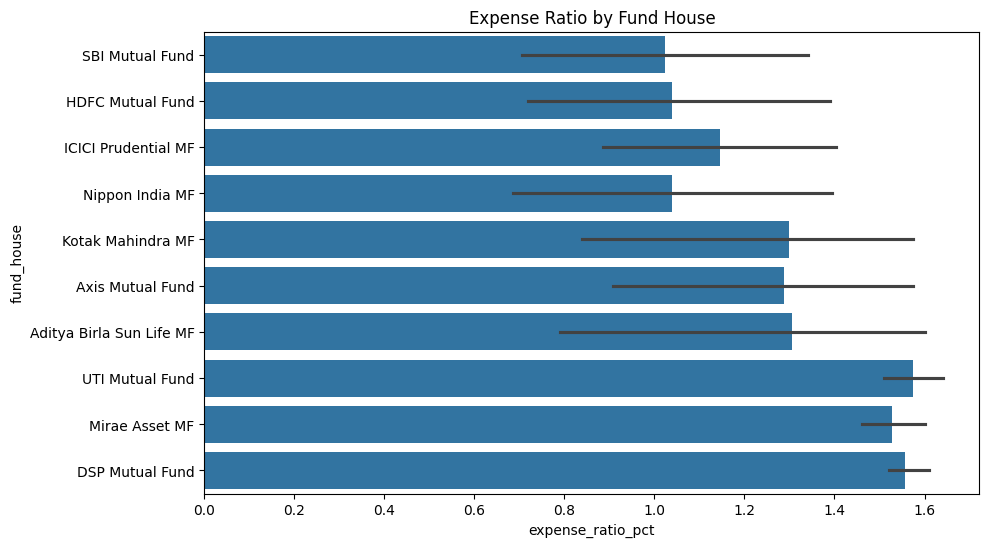

In [18]:
# Chart 3: Expense Ratio
sns.barplot(
    x="expense_ratio_pct",
    y="fund_house",
    data=performance
)

plt.title("Expense Ratio by Fund House")
plt.show()

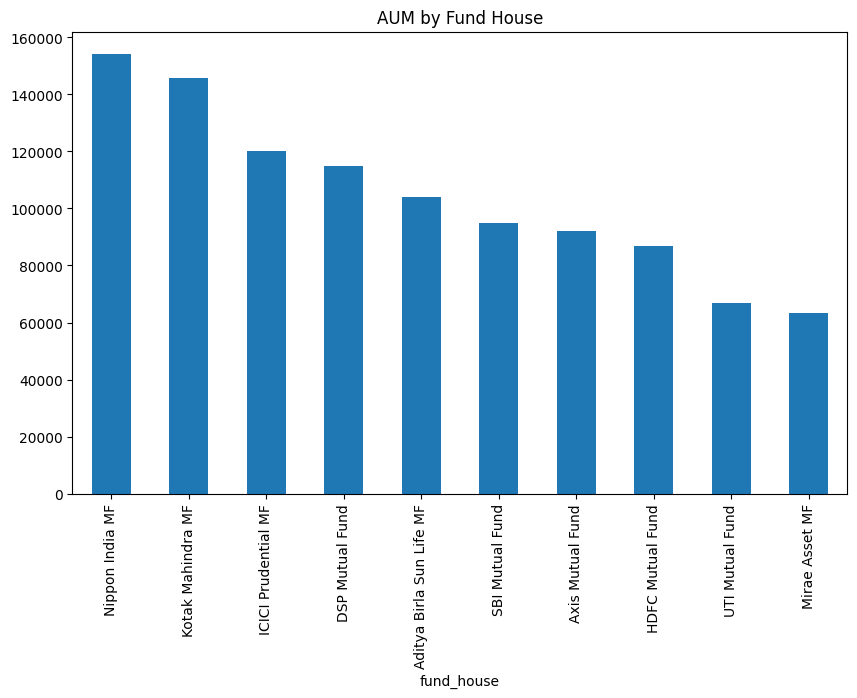

In [19]:
# Chart 2: AUM Growth
aum = (
    performance.groupby("fund_house")
    ["aum_crore"]
    .sum()
    .sort_values(ascending=False)
)

aum.plot(kind="bar")

plt.title("AUM by Fund House")
plt.show()

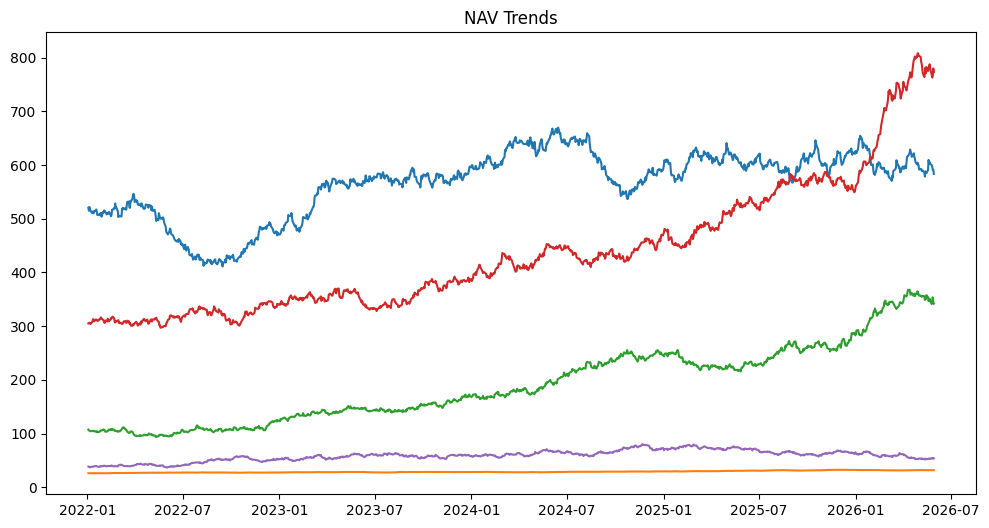

In [20]:
# Chart 1: NAV Trend Analysis
nav["date"] = pd.to_datetime(nav["date"])

plt.figure(figsize=(12,6))

for code in nav["amfi_code"].unique()[:5]:
    subset = nav[nav["amfi_code"] == code]
    plt.plot(subset["date"], subset["nav"])

plt.title("NAV Trends")
plt.show()

In [4]:
import pandas as pd

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

performance = pd.read_csv(
    "../data/processed/07_scheme_performance_clean.csv"
)

transactions = pd.read_csv(
    "../data/processed/08_investor_transactions_clean.csv"
)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.rcParams["figure.figsize"] = (10,6)